**Linear Regression model**-Predicting Scores Based on Study Hours


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



df = pd.read_csv("/content/student_scores - student_scores.csv")

print("First 5 rows:")
print(df.head())


First 5 rows:
   Hours  Scores
0    2.5      21
1    5.1      47
2    3.2      27
3    8.5      75
4    3.5      30



Dataset Shape: (25, 2)
Number of Rows: 25
Number of Columns: 2

Statistical Summary:
           Hours     Scores
count  25.000000  25.000000
mean    5.012000  51.480000
std     2.525094  25.286887
min     1.100000  17.000000
25%     2.700000  30.000000
50%     4.800000  47.000000
75%     7.400000  75.000000
max     9.200000  95.000000

Median:
Hours      4.8
Scores    47.0
dtype: float64

Missing Values:
Hours     0
Scores    0
dtype: int64


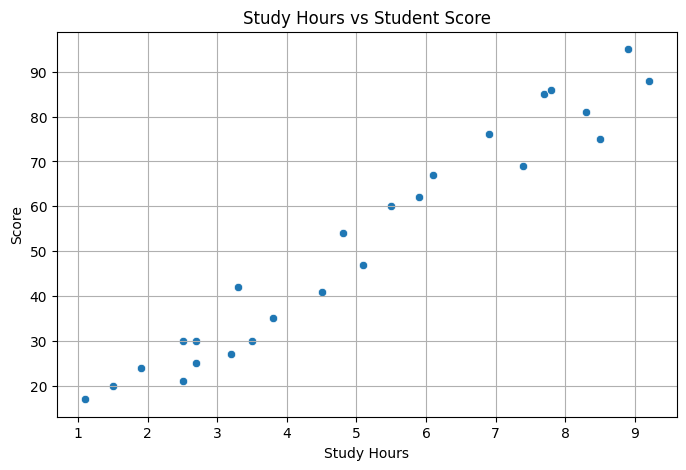

In [21]:
# 2. Exploratory Data Analysis (EDA)

print("\nDataset Shape:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nStatistical Summary:")
print(df.describe())

print("\nMedian:")
print(df.median(numeric_only=True))

print("\nMissing Values:")
print(df.isnull().sum())


df = df.dropna(subset=["Hours", "Scores"])

# Scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Hours", y="Scores")
plt.title("Study Hours vs Student Score")
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.grid(True)
plt.show()


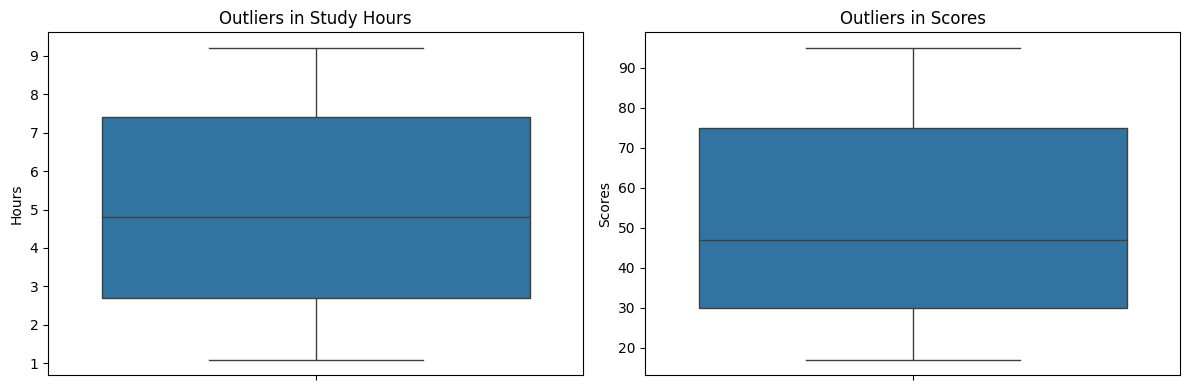


Potential outliers in Hours:
Empty DataFrame
Columns: [Hours, Scores]
Index: []

Potential outliers in Scores:
Empty DataFrame
Columns: [Hours, Scores]
Index: []


In [22]:
# 3. Data Preprocessing

# Check outliers using boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=df["Hours"], ax=axes[0])
axes[0].set_title("Outliers in Study Hours")

sns.boxplot(y=df["Scores"], ax=axes[1])
axes[1].set_title("Outliers in Scores")

plt.tight_layout()
plt.show()

# Detect potential outliers using IQR
for col in ["Hours", "Scores"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) | (df[col] > upper)
    ]

    print(f"\nPotential outliers in {col}:")
    print(outliers)


In [23]:
# 4. Splitting the Data

X = df[["Hours"]]
y = df["Scores"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)



Training Features Shape: (20, 1)
Testing Features Shape: (5, 1)
Training Target Shape: (20,)
Testing Target Shape: (5,)


In [24]:

# 5. Building the Linear Regression Model

model = LinearRegression()
model.fit(X_train, y_train)

print("\nIntercept:", model.intercept_)
print("Coefficient:", model.coef_[0])



Intercept: 2.826892353899737
Coefficient: 9.682078154455697


In [25]:
# 6. Model Evaluation

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Squared Error:", mse)
print("R2 Score:", r2)

results = pd.DataFrame({
    "Actual Score": y_test.to_numpy(),
    "Predicted Score": y_pred
})

print("\nActual vs Predicted Scores:")
print(results)


Mean Squared Error: 18.943211722315272
R2 Score: 0.9678055545167994

Actual vs Predicted Scores:
   Actual Score  Predicted Score
0            81        83.188141
1            30        27.032088
2            21        27.032088
3            76        69.633232
4            62        59.951153


In [26]:
# 7. Testing on Unseen Data

new_data = pd.DataFrame({"Hours": [9]})
predicted_score = model.predict(new_data)

print("\nPredicted Score for 9 Study Hours:",
      predicted_score[0])



Predicted Score for 9 Study Hours: 89.965595744001


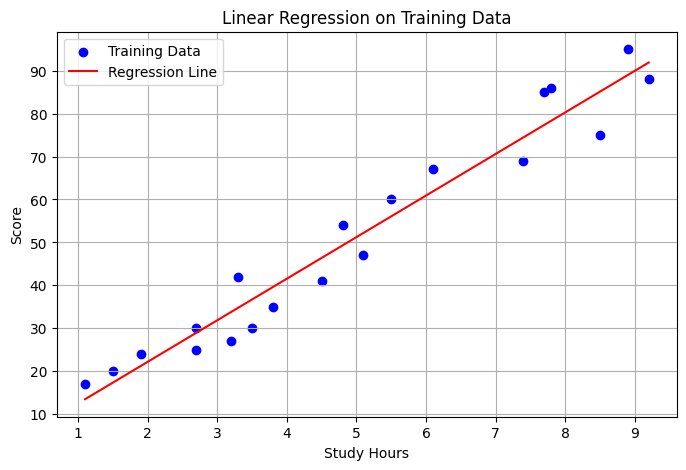

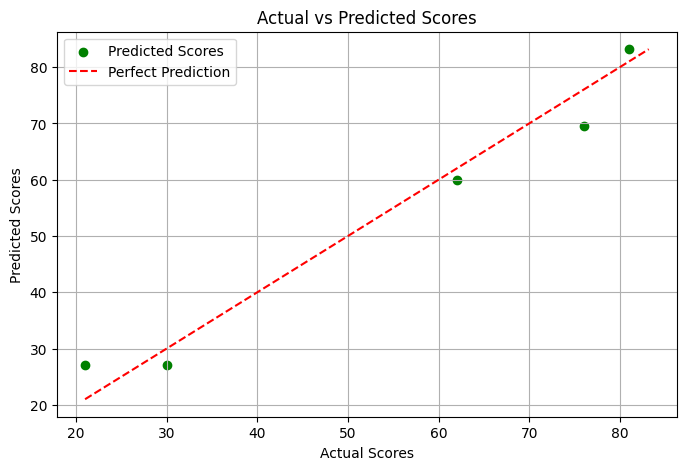

In [27]:



# 8. Visualization

# Regression line on training data
plt.figure(figsize=(8, 5))

plt.scatter(
    X_train["Hours"], y_train,
    color="blue",
    label="Training Data"
)

sorted_index = np.argsort(X_train["Hours"].to_numpy())

plt.plot(
    X_train["Hours"].to_numpy()[sorted_index],
    model.predict(X_train)[sorted_index],
    color="red",
    label="Regression Line"
)

plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.title("Linear Regression on Training Data")
plt.legend()
plt.grid(True)
plt.show()


# Actual vs predicted scores
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test, y_pred,
    color="green",
    label="Predicted Scores"
)

min_score = min(y_test.min(), y_pred.min())
max_score = max(y_test.max(), y_pred.max())

plt.plot(
    [min_score, max_score],
    [min_score, max_score],
    color="red",
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Scores")
plt.legend()
plt.grid(True)
plt.show()